In [43]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2](https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk)
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [44]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader
from gensim.models import KeyedVectors
from autocorrect import Speller
import os
import simplejson as sj

import pandas as pd
from typing import List, Callable, Dict
from collections import OrderedDict
import umap

import re

from sklearn.metrics.pairwise import cosine_similarity

# disable wandb
import wandb
wandb.init(mode="disabled")


## hashtags segmenter: https://github.com/grantjenks/python-wordsegment
import wordsegment as ws 
ws.load()

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

LEMMATIZED_TRAIN_DATA_FILE = "training_data_lemm.csv"
LEMMATIZED_VALIDATION_DATA_FILE = "validation_data_lemm.csv"
LEMMATIZED_TEST_DATA_FILE = "test_data_lemm.csv"

LSTM_VALIDATION_RESULT_FILE = "lstm_validation_results.csv"

In [45]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: mps


# Data Cleaning

In [46]:
## REGEXs
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z +_<>]')
HASHTAG_REGEX = re.compile('#\w+')
MENTION_REGEX = re.compile("@\w+")
URL_REGEX = re.compile('https?://(?:www\.)?[\w-]+\.[\w/._-]+')
## SPECIAL TOKENs
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_GREATER_THAN = " <GREATER_THAN> "
TOKEN_LEFT_SINGLE_QUOTE = " <LEFT_SINGLE_QUOTE> "
TOKEN_RIGHT_SINGLE_QUOTE = " <RIGHT_SINGLE_QUOTE> "
TOKEN_LEFT_DOUBLE_QUOTE = " <LEFT_DOUBLE_QUOTE> "
TOKEN_RIGHT_DOUBLE_QUOTE = " <RIGHT_DOUBLE_QUOTE> "
TOKEN_ELLIPSIS = " <ELLIPSIS> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_URL = " <URL> "
TOKEN_HASHTAG_START = " <HASHTAG_START> "
TOKEN_HASHTAG_END = " <HASHTAG_END> "

try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [47]:
def lower(text):
    """
    Converts all characters in the input text to lowercase.

    :param text: A string of text.

    :return:
        - A string where all characters are converted to lowercase.
    """
    return text.lower()

def strip_text(text):
    """
    Strips leading and trailing whitespace characters from the input text.

    :param text: A string of text.

    :return:
        - A string with leading and trailing whitespace removed.
    """
    return text.strip()

def contains_emoji(text):
    """
    Checks if the input text contains any emoji characters.

    :param text: A string of text.

    :return:
        - True if any emoji is found in the text, False otherwise.
    """
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text):
    """
    Checks if the input text contains any mentions (user handles).

    :param text: A string of text.

    :return:
        - A list of all mentions found in the text (empty list if none).
    """
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text):
    """
    Replaces any URLs in the input text with a predefined token.

    :param text: A string of text.

    :return:
        - A string with URLs replaced by a token.
    """
    return re.sub(URL_REGEX, TOKEN_URL, text)

def remove_angle_brackets(text):
    """
    Replaces angle brackets and their associated symbols with predefined tokens or strings.

    :param text: A string of text.

    :return:
        - A string where angle brackets are replaced with predefined tokens.
    """
    text.replace("&amp", " and ")
    text.replace("<", TOKEN_LESSER_THAN)
    text.replace(">", TOKEN_GREATER_THAN)
    return text

def emoji2description(text):
    """
    Replaces any emoji characters in the input text with their descriptions.

    :param text: A string of text.

    :return:
        - A string where emojis are replaced with their textual descriptions.
    """
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    """
    Applies a text encoding function to a specified column in a DataFrame.

    :param data: A DataFrame containing the data.
    :param encoding: A function to apply to the text data.
    :param column: The column of the DataFrame to encode (default is 'tweet').

    :return:
        - The DataFrame with the encoded column.
    """
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    """
    Replaces quote symbols in the input text with predefined token representations.

    :param text: A string of text.

    :return:
        - A string where quote symbols are replaced with predefined tokens.
    """
    text = text.replace("‘", TOKEN_LEFT_SINGLE_QUOTE)
    text = text.replace("’", TOKEN_RIGHT_SINGLE_QUOTE)
    text = text.replace("“", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("”", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("...", TOKEN_ELLIPSIS)
    return text

def replace_mention(text):
    """
    Replaces mentions (user handles) in the input text with their entity type or part of speech.

    :param text: A string of text that may contain mentions (e.g., user handles like @username).

    :return:
        - A string where each mention is replaced by its entity type (if recognized), 
          or part of speech (if no entity is found).
        - If no mentions are found, the original text is returned unchanged.
    """
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f" <{sub[0]}> ")
            else:
                new_sen = new_sen.replace(m, f" <{[c.pos_ for c in doc][0]}> ")
        return new_sen
    else:
        return text    
    
def replace_hashtag(text):
    """
    Replaces hashtags, by segmenting hashtags and adding special tokens in front and at the end of it.
    """
    def segment(x) :
        return TOKEN_HASHTAG_START+' '.join(ws.segment(x))+TOKEN_HASHTAG_END
    return re.sub(HASHTAG_REGEX, lambda x: segment(x.group(0)), text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_unwanted_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub(' ', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [48]:
def majority_vote(lst):
    """
    Apply a majority vote to a list of votes.

    :param lst: A list of strings, where each string is either "YES" or "NO", 
                representing individual votes.

    :return:
        - 1 if "YES" is the most common vote.
        - 0 if "YES" is not the most common vote.
    """
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0


def yes_probability(lst):
    """
    Calculates the probability of a "YES" label in a list of votes.

    :param lst: A list of strings, where each string is either "YES" or "NO", 
                representing individual votes.

    :return:
        - A float representing the probability of "YES" votes in the list.
        - Returns `None` if the list contains no "YES" or "NO" votes.
    """
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")

    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total


def generate_labels_task1(data):
    """
    Generates hard and soft labels for task 1 from the dataset by processing the 'labels_task1' column.

    :param data: DataFrame containing the dataset, which includes a 'labels_task1' column 
                 with annotations for task 1 and other metadata.

    :return:
        - A DataFrame with added columns:
            - 'hard_label_task1': Hard labels obtained through majority vote.
            - 'soft_label_task1': Soft labels calculated as the probability of a "yes" label.
        - Unnecessary columns related to annotator metadata and other tasks are removed.
    """
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data


def load_dataset(file_path):
  """
  Loads a dataset from a JSON file and transposes it.

  :param file_path: Path to the JSON file containing the dataset.

  :return:
      - A DataFrame where the rows and columns of the original JSON data are transposed.
  """
  return pd.read_json(file_path).T


def load_and_preprocess_dataset(file_path, verbose = True, index_to_print=1):
    """
    Loads a dataset from a JSON file, preprocesses it for a classification task, and applies a series of 
    text encoding transformations.

    :param file_path: Path to the JSON file containing the dataset.
    :param verbose: If True, prints the intermediate steps and transformations for debugging.
    :param index_to_print: Index of the row to print at each step for debugging purposes. Default is 1.

    :return:
        - A DataFrame with the preprocessed dataset, ready for model training or evaluation.
    """
    # Load and transpose the data
    data = pd.read_json(file_path).T
    if verbose:
      print(f"Initial Data (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Generate labels for task 1
    data = generate_labels_task1(data)
    if verbose:
      print(f"After generate_labels_task1 (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Add 'original' column (to remove)
    data['original'] = data['tweet']

    # Keep only necessary columns
    columns_to_keep = ['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1', 'original']
    data = data[columns_to_keep]
    if verbose:
      print(f"After keeping specific columns (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Filter for English-only data
    data = filter_english_only(data)
    if verbose:
      print(f"After filter_english_only (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Apply each encoding function and print the result
    encoding_functions = [
        remove_angle_brackets,
        emoji2description,
        replace_mention,
        replace_hashtag,
        replace_urls_with_token,
        replace_quote_symbols,
        # replace_special_characters,
        lower,
        filter_out_unwanted_symbols,
        remove_stopwords,
        strip_text
    ]

    for func in encoding_functions:
        data = encode_data_with_function(data, func)
        if verbose:
          print(f"After {func.__name__} (index == {index_to_print}):\n", data.loc[index_to_print]['tweet'] if index_to_print in data.index else "Index not found")

    return data


def filter_english_only(df):
    """
    Filters the dataset to include only rows where the language is English.

    :param df: A DataFrame containing a 'lang' column that specifies the language of each row.

    :return:
        - A new DataFrame containing only rows where the 'lang' column includes 'en'.
    """
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [49]:
#Debug purpose
load_and_preprocess_dataset("data/training.json", verbose=True, index_to_print=202722)

Initial Data (index == 202722):
 id_EXIST                                                        202722
lang                                                                en
tweet                Today’s women are not the same as women were i...
number_annotators                                                    6
annotators           [Annotator_720, Annotator_721, Annotator_722, ...
gender_annotators                                   [F, F, M, M, M, F]
age_annotators                  [18-22, 23-45, 18-22, 23-45, 46+, 46+]
labels_task1                              [YES, NO, NO, YES, YES, YES]
labels_task2               [JUDGEMENTAL, -, -, DIRECT, DIRECT, DIRECT]
labels_task3         [[IDEOLOGICAL-INEQUALITY], [-], [-], [STEREOTY...
split                                                         TRAIN_EN
Name: 202722, dtype: object
After generate_labels_task1 (index == 202722):
 id_EXIST                                                       202722
lang                                    

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...
...,...,...,...,...,...,...
203256,203256,en,idk <right_single_quote> bitches think half as...,1,1.000000,idk why y’all bitches think having half your a...
203257,203257,en,part experiment <org> learning though little b...,1,1.000000,This has been a part of an experiment with @Wo...
203258,203258,en,<left_double_quote> take already <left_double_...,1,0.666667,"""Take me already"" ""Not yet. You gotta be ready..."
203259,203259,en,<person> look like whore lh <url>,1,1.000000,@clintneedcoffee why do you look like a whore?...


In [50]:
# load and preprocess Training data
processed_training_data = load_and_preprocess_dataset("data/training.json", verbose=False)
print('Finished preprocessing training')
# load and preprocess Validation data
processed_validation_data = load_and_preprocess_dataset("data/validation.json", verbose=False)
print('Finished preprocessing validation')
# load and preprocess Test data
processed_test_data = load_and_preprocess_dataset("data/test.json", verbose=False)
print('Finished preprocessing test')

Finished preprocessing training
Finished preprocessing validation
Finished preprocessing test


# Data Visualization
Let's get some visualization of the processed data.

In [51]:
# describes of target labels
display(processed_training_data.describe())
display(processed_validation_data.describe())
display(processed_test_data.describe())


,hard_label_task1,soft_label_task1
count,3260.000000,3260.000000
mean,0.404601,0.416104
std,0.490890,0.340154
min,0.000000,0.000000
25%,0.000000,0.166667
50%,0.000000,0.333333
75%,1.000000,0.666667
max,1.000000,1.000000


,hard_label_task1,soft_label_task1
count,177.000000,177.000000
mean,0.429379,0.423729
std,0.496392,0.343117
min,0.000000,0.000000
25%,0.000000,0.166667
50%,0.000000,0.333333
75%,1.000000,0.666667
max,1.000000,1.000000


,hard_label_task1,soft_label_task1
count,312.000000,312.000000
mean,0.451923,0.458868
std,0.498483,0.356133
min,0.000000,0.000000
25%,0.000000,0.166667
50%,0.000000,0.333333
75%,1.000000,0.833333
max,1.000000,1.000000


In [52]:
# some examples of each dataset
display(processed_training_data.head())
display(processed_validation_data.head())
display(processed_test_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...


,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
400001,400001,en,<noun> <left_double_quote> smile love pretend ...,0,0.333333,"@Mike_Fabricant “You should smile more, love. ..."
400002,400002,en,<punct> <propn> <norp> right push opposite dir...,1,0.666667,@BBCWomansHour @LabWomenDec @EverydaySexism Sh...
400003,400003,en,<hashtag_start> everyday sexism <hashtag_end> ...,1,0.833333,#everydaysexism Some man moving my suitcase in...
400004,400004,en,<aux> <noun> lol gamergate go boogieman maybe ...,0,0.166667,@KolHue @OliverJia1014 lol gamergate the go to...
400005,400005,en,<propn> negativity gamergate people want act l...,0,0.333333,@ShelfStoriesGBL To me this has the same negat...


,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
400178,400178,en,1st day pool beautiful sunday ny bad dared go ...,0,0.000000,1st day at the pool on a beautiful Sunday in N...
400179,400179,en,<left_double_quote> like outfit except dress f...,1,0.833333,“I like your outfit too except when i dress up...
400180,400180,en,<product> pleading face sparkling heart though...,0,0.000000,"@KNasFanFic 🥺💖 same, though!!! the angst just ..."
400181,400181,en,<noun> <x> fuck cunt tried vote multiple times,1,0.833333,@themaxburns @GOP Fuck that cunt. Tried to vot...
400182,400182,en,<org> u gotta say shit like <left_double_quote...,1,1.000000,@ultshunnie u gotta say some shit like “i’ll f...


In [53]:
# define target column
target = "hard_label_task1"

In [54]:
processed_training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

Train '0:1' score ratio --> 1.47 : 1
Valid  '0:1' score ratio --> 1.33 : 1


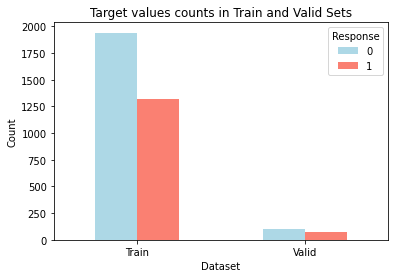

In [55]:
train_counts = processed_training_data[target].value_counts()
validation_counts = processed_validation_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Valid': validation_counts
}).T  # Transpose to have "yes" and "no" as columns

# save negative/positive ratios
train_neg_over_pos = counts_df[0]['Train']/counts_df[1]['Train']
validation_neg_over_pos = counts_df[0]['Valid']/counts_df[1]['Valid']
print(f"Train '0:1' score ratio --> {train_neg_over_pos:.2f} : 1")
print(f"Valid  '0:1' score ratio --> {validation_neg_over_pos:.2f} : 1")

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Target values counts in Train and Valid Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

> The target values are not equally balanced, but are correctly selected for the validation set to be representative of the same distribution.


## Lemmatization

In [56]:
def get_wordnet_key(pos_tag):
    """
    Converts a part-of-speech tag into a WordNet part-of-speech key.

    :param pos_tag: A string representing the part-of-speech tag of a word.

    :return:
        - A WordNet part-of-speech key (ADJ, VERB, NOUN, ADV, or 'n' for unknown tags).
    """
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer(), spell_checker=True, spell=Speller(lang='en')):
    """
    Lemmatizes the input text by performing tokenization, spelling correction (optional), and lemmatization.

    :param text: A string of text to be lemmatized.
    :param lemmatizer: A WordNetLemmatizer object for lemmatization (default: WordNetLemmatizer).
    :param tokenizer: A tokenizer object (default: WhitespaceTokenizer).
    :param spell_checker: A boolean indicating whether to apply spelling correction (default: True).
    :param spell: A spell checker object for spelling correction (default: Speller with 'en' language).

    :return:
        - A string of lemmatized text with corrected spelling and proper word forms.
    """
    _text = []
    # segment all words that does not contain a '<' inside
    for t in text.split(" "):
        _text += [t if "<" in t else ' '.join(ws.segment(t))]
    text = ' '.join(_text)

    # check for mis-spelling of words
    tokens = tokenizer.tokenize(text)
    if spell_checker:
      tokens = [spell(w) for w in tokens]
    # lemmatize words by their semantics
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

In [57]:
def load_lemmatized_data(preprocessed_data, lem_fn=lem_text , path=""):
    """
    Loads lemmatized data from a file if it exists, otherwise applies lemmatization to the data and saves it.

    :param preprocessed_data: A DataFrame containing the preprocessed text data.
    :param lem_fn: The lemmatization function to apply (default: lem_text).
    :param path: The path to the file where the lemmatized data will be stored or loaded from.

    :return:
        - A DataFrame containing the lemmatized data.
    """
    if not os.path.isfile(path):
        lem_data = encode_data_with_function(preprocessed_data,lem_fn)
        lem_data.to_csv(path)
        return lem_data
    else:
        return pd.read_csv(path)

In [58]:
# load lemmatized training data
print("Lemmatizing training data.")
lem_training_data = load_lemmatized_data(processed_training_data, path=LEMMATIZED_TRAIN_DATA_FILE)
# load lemmatized validation data
print("Lemmatizing validation data.")
lem_validation_data = load_lemmatized_data(processed_validation_data, path=LEMMATIZED_VALIDATION_DATA_FILE)
# load lemmatized test data
print("Lemmatizing test data.")
lem_test_data = load_lemmatized_data(processed_test_data, path=LEMMATIZED_TEST_DATA_FILE)

Lemmatizing training data.
Lemmatizing validation data.
Lemmatizing test data.


# Task 3 - Text encoding

In [59]:
EMB_DIM = 50

In [60]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    # https://github.com/piskvorky/gensim-data?tab=readme-ov-file#datasets
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"
    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'glove-twitter':
        download_path = "glove-twitter-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print("Glove-twitter: 25, 50, 100, 200")
        print('FastText: 300')
        raise e

    return emb_model

def build_vocabulary(df: pd.DataFrame, add_glove_tokens = False, model = None, additional_tokens = None) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Builds a vocabulary that is the union of tokens from the dataset and model embeddings.

    :param df: pandas DataFrame containing the dataset (column 'tweet' with sentences).
    :param model: Model object containing pre-trained embeddings.
    :return:
      - idx_to_word: Dictionary mapping vocabulary index to word.
      - word_to_idx: Dictionary mapping word to vocabulary index.
      - word_listing: List of unique terms in the vocabulary.
    """
    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()
    
    # Add tokens from training set
    curr_idx = 0
    for sentence in tqdm(df['tweet'].values, desc="Building vocabulary from dataset"):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1
    
    # Add tokens from GloVe (via Gensim)
    if add_glove_tokens:
      for token in tqdm(model.key_to_index, desc="Adding GloVe tokens"):
          if token not in word_to_idx:
              word_to_idx[token] = curr_idx
              idx_to_word[curr_idx] = token
              curr_idx += 1

    # Add additional special tokens
    if additional_tokens is not None and isinstance(additional_tokens, List):
        for token in additional_tokens:
            word_to_idx[token] = curr_idx
            idx_to_word[curr_idx] = token
            curr_idx += 1
        
    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

def evaluate_vocabulary(idx_to_word: Dict[int, str], word_to_idx: Dict[str, int],
                        word_listing: List[str], df: pd.DataFrame, check_default_size: bool = False):
    """
    Evaluates the consistency and correctness of the vocabulary mappings and word listings.

    :param idx_to_word: A dictionary mapping indices to words.
    :param word_to_idx: A dictionary mapping words to indices.
    :param word_listing: A list of words in the vocabulary.
    :param df: A DataFrame containing text data to check against.
    :param check_default_size: A boolean flag to check for default vocabulary size (default: False).

    :return:
        - None. The function prints checks for vocabulary consistency and correctness.
    """
    print("[Vocabulary Evaluation] Size checking...")
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    print("[Vocabulary Evaluation] Content checking...")
    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    print("[Vocabulary Evaluation] Consistency checking...")
    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    print("[Vocabulary Evaluation] Toy example checking...")
    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold", "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df['tweet'].values).split())
    assert set(toy_word_listing) == toy_valid_vocabulary

def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [61]:
embedding_model = load_embedding_model(model_type="glove-twitter",
                                       embedding_dimension=EMB_DIM)

In [62]:
# let's peek to the embedding matrix values distribution
df_embed = pd.DataFrame(data=embedding_model.vectors)
df_embed.describe()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
count,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,...,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06
mean,-2.189694e-01,1.726908e-01,-5.617134e-02,6.307274e-02,9.606626e-03,-2.346111e-01,-1.673192e-01,-2.561416e-01,1.299083e-01,-3.417983e-01,...,8.865857e-01,-1.498127e-02,1.021143e-01,-1.295955e-01,-3.283582e-01,1.301438e-01,-2.061018e-02,5.735761e-02,1.400820e-01,2.258864e-01
std,6.761081e-01,6.944407e-01,6.916828e-01,6.787786e-01,6.724812e-01,6.458723e-01,6.574651e-01,6.568925e-01,6.580209e-01,6.958572e-01,...,6.979791e-01,7.033525e-01,6.897094e-01,6.691399e-01,6.530790e-01,6.655709e-01,6.396263e-01,6.755373e-01,6.775005e-01,7.008290e-01
min,-6.841300e+00,-5.047700e+00,-5.438000e+00,-5.890500e+00,-5.565400e+00,-5.154800e+00,-4.560500e+00,-6.026900e+00,-6.973900e+00,-5.919400e+00,...,-5.068500e+00,-6.539600e+00,-4.826100e+00,-5.101300e+00,-6.305100e+00,-5.560800e+00,-6.061000e+00,-4.887500e+00,-5.418700e+00,-5.085200e+00
25%,-6.413400e-01,-2.436100e-01,-4.679675e-01,-3.681900e-01,-4.101000e-01,-6.339200e-01,-5.818400e-01,-6.666175e-01,-2.842500e-01,-7.918400e-01,...,4.949600e-01,-4.598200e-01,-3.346475e-01,-5.460300e-01,-7.529800e-01,-2.694100e-01,-4.273100e-01,-3.651200e-01,-2.839800e-01,-2.194600e-01
50%,-2.189900e-01,2.007850e-01,-4.527100e-02,5.317900e-02,4.772650e-03,-2.469000e-01,-1.770900e-01,-2.591700e-01,1.371100e-01,-3.565800e-01,...,9.351600e-01,-2.827900e-02,1.090500e-01,-1.173900e-01,-3.416500e-01,1.419800e-01,-2.246000e-02,6.179700e-02,1.519800e-01,2.088050e-01
75%,2.080900e-01,6.189800e-01,3.714400e-01,4.816900e-01,4.271400e-01,1.549200e-01,2.374700e-01,1.492100e-01,5.490300e-01,9.211150e-02,...,1.337700e+00,4.182375e-01,5.358700e-01,3.018000e-01,8.437975e-02,5.460100e-01,3.849000e-01,4.888800e-01,5.653500e-01,6.511900e-01
max,5.123200e+00,5.519100e+00,5.251400e+00,6.513400e+00,6.321600e+00,5.412600e+00,4.639100e+00,5.666800e+00,5.547700e+00,4.933300e+00,...,5.409900e+00,5.424700e+00,5.582800e+00,5.098700e+00,5.321000e+00,4.581900e+00,4.588900e+00,4.855900e+00,5.119900e+00,5.938800e+00


### Add Padding Token and Unkown Token to Vocabulary
It's crucial deal with OOV map them all to a proper UNKNOEN_TOKEN, to avoid runtime error on embedding matrix lookups.

A PADDING_TOKEN is added to make sentences of the same length when required (e.g. when collating all sentences in a batch).

In [63]:
PADDING_TOKEN="<pad>"
UNKNOWN_TOKEN="<unk>"

Create an initial vocab with words from training data (if add_glove_tokens = True add also GloVe precomputed tokens)

In [64]:
print("Building Training data Vocabulary.")
train_idx_to_word, train_word_to_idx, train_word_listing = build_vocabulary(lem_training_data, add_glove_tokens = True, model = embedding_model, additional_tokens=[PADDING_TOKEN, UNKNOWN_TOKEN])
print(f'[Debug] Index -> Word vocabulary size: {len(train_idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(train_word_to_idx)}')
print(f'[Debug] Some words: {[(train_idx_to_word[idx], idx) for idx in np.arange(10) + 1]}')

Building Training data Vocabulary.


Adding GloVe tokens: 100%|███████| 1193514/1193514 [00:00<00:00, 2567833.47it/s]


[Debug] Index -> Word vocabulary size: 1194031
[Debug] Word -> Index vocabulary size: 1194031
[Debug] Some words: [('lay', 1), ('blame', 2), ('bastard', 3), ('murder', 4), ('novel', 5), ('idea', 6), ('know', 7), ('<url>', 8), ('write', 9), ('uni', 10)]


In [65]:
print("Vocabulary evaluation...")
evaluate_vocabulary(train_idx_to_word, train_word_to_idx, train_word_listing, lem_training_data)
print("Evaluation completed!")

Vocabulary evaluation...
[Vocabulary Evaluation] Size checking...
[Vocabulary Evaluation] Content checking...


100%|████████████████████████████| 1194031/1194031 [00:00<00:00, 2763187.98it/s]


[Vocabulary Evaluation] Consistency checking...


Building vocabulary from dataset: 100%|█| 3260/3260 [00:00<00:00, 293982.74it/s]


[Vocabulary Evaluation] Toy example checking...


Building vocabulary from dataset: 100%|█████████| 2/2 [00:00<00:00, 9664.29it/s]

Evaluation completed!


### Check OOV terms in Training Data

In [66]:
train_oov_terms = check_OOV_terms(embedding_model, train_word_listing)
train_oov_percentage = float(len(train_oov_terms)) * 100 / len(train_word_listing)
print(f"Total OOV terms in training: {len(train_oov_terms)} ({train_oov_percentage:.2f}%)")
print(train_oov_terms)

Total OOV terms in training: 517 (0.04%)
['5', '2018', '500', '6', '<noun>', '238', '<part>', '2002', 'ambig', 'sissification', '73', '100horrormoviesin92', 'nonviable', '1980', '1988', 'ruggerio', '43', '1619', '81', 'deeded', '8m', '02', '2022', 'baryon', '56k', 'weightlift', '10km', 'p4ties', 'nonconforming', '18', 'sauropod', '2nd', '1987', '1930s', 'anupama', 'mechanization', '1st', '11th', '1866', 'carmelite', '90k', '180', '38', '14400', '51', '000s', 'keep1er', '<product>', '17m', 'actionaid', 'not8', 'prophetically', 'dishevel', '8', '1996', 'tudes', '00', 'volodymyr', 'fair1', 'p55x8wjgxk', '33', 'sensitization', '3d', '<hashtag_end>', '88', 'roofed', '333', 'racialized', 'arinanaxstyles420', '2005', '300', 'wh0r3s', 'votebluein2022', 'maccoby', '2000', 'anglicise', 'cinephiles', '2011', '<org>', 'shirtwaist', 'xx9srv1d', '498', '85', '9', 'radio3', '75', '80', 'bff22', 'gaisha', 'go2', '164', 'paternalistic', '59', '<gpe>', '2030s', '988', '<prop>', '5g', 'poet2021', 'postst

Save Vocabulary.

In [67]:
#Saving the vocabulary
vocab_path = Path.cwd().joinpath('data', 'vocab.json')

print(f"Saving vocabulary to {vocab_path}")
with vocab_path.open(mode='w') as f:
    sj.dump(train_word_to_idx, f, indent=4)
print("Saving completed!")

Saving vocabulary to /Users/utenteadmin/Desktop/UNIBO/2024-2025/1° semestre/Natural Language Processing/Assignment 1/NLP_AssignmentOne/data/vocab.json
Saving completed!


### Dealing with the Embedding Matrix
Let's build an embedding matrix starting from the one of the pretrained embedding model.

In [68]:
def find_closest_embedding(oov_word, embedding_model, embedding_dimension):
    """
    Finds the most similar word's embedding for the given OOV word.

    :param oov_word: OOV word (str)
    :param embedding_model: pre-trained word embedding model (gensim)
    :param embedding_dimension: dimensionality of the embeddings
    :return:
        - embedding vector of the most similar word
    """
    vocab_words = list(embedding_model.key_to_index.keys())
    vocab_vectors = np.array([embedding_model[word] for word in vocab_words])
    oov_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)  # Fallback vector

    # Compute similarity
    similarities = cosine_similarity([oov_vector], vocab_vectors).flatten()
    closest_idx = np.argmax(similarities)
    return vocab_vectors[closest_idx]

def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str],
                           dataset_type: str = 'train') -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in tqdm(word_to_idx.items()):
        if dataset_type == 'train':
            try:
                embedding_vector = embedding_model[word]
            except KeyError:
                embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        elif dataset_type in ['validation', 'test']:
            if word in oov_terms:
                embedding_vector = find_closest_embedding(word, embedding_model, embedding_dimension)
            else:
                try:
                    embedding_vector = embedding_model[word]
                except KeyError:
                    embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)
        else:
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
    return embedding_matrix

Build an embedding matrix and use it to update the pretrained one with the OOV terms new vectors. 

In [69]:
embedding_matrix = build_embedding_matrix(embedding_model, EMB_DIM, train_word_to_idx, len(train_word_to_idx), train_oov_terms)
embedding_model.add_vectors(train_word_listing, embedding_matrix)
print(f"Embedding matrix shape: {embedding_model.vectors.shape}")

100%|█████████████████████████████| 1194031/1194031 [00:01<00:00, 692512.66it/s]


Embedding matrix shape: (1194031, 50)


### Manage OOV terms in Validation and Test data.
Build Validation and Test data vocabulary.

In [70]:
print("Building Validation Word listing.")
_, _, validation_word_listing = build_vocabulary(lem_validation_data, add_glove_tokens = False, model = embedding_model)
print("Building Test Word listing.")
_, _, test_word_listing = build_vocabulary(lem_test_data, add_glove_tokens = False, model = embedding_model)

Building Validation Word listing.


Building vocabulary from dataset: 100%|███| 177/177 [00:00<00:00, 135029.43it/s]


Building Test Word listing.


Building vocabulary from dataset: 100%|███| 312/312 [00:00<00:00, 118846.87it/s]


Find OOV of Test and Validation data w.r.t. to training data vocabulary.

In [71]:
validation_oov_terms = check_OOV_terms(embedding_model, validation_word_listing)
validation_oov_percentage = float(len(validation_oov_terms)) * 100 / len(validation_word_listing)
print(f"Total OOV terms in Validation Data: {len(validation_oov_terms)} ({validation_oov_percentage:.2f}%)")
print(validation_oov_terms)
test_oov_terms = check_OOV_terms(embedding_model, test_word_listing)
test_oov_percentage = float(len(test_oov_terms)) * 100 / len(test_word_listing)
print(f"Total OOV terms in Test Data: {len(test_oov_terms)} ({test_oov_percentage:.2f}%)")
print(test_oov_terms)

Total OOV terms in Validation Data: 19 (1.19%)
['kimjiyoungborn1982', '68', '20hr', 'hw3say', 'j5b9hs39w', '2any', 'curid', '55g', '114', 'ex7chan3g', '1986', 'jgemyxyogg', 'kiji', '175', '184m', 'ruqaiijah', 'canonize', 'gma23', 'nihilo']
Total OOV terms in Test Data: 25 (1.14%)
['debilitate', '1051', 'demonology', 'ns3m', 'overarch', 'mojassim80', '10off', 'peerage', '1950s', '14', 'cre8tiveconla', 'ramification', '8am', '031b0038', 'cre8tivecon', '80x', 'wknight', 'civilly', 'ieee', '100m', '40x', 'mearsheimer', '315', 'underlies', 'disembody']


Map OOV of Test and Validation data to UNKNOWN_TOKEN.

In [72]:
def replace_OOV_words(oov_words, unknown_token=UNKNOWN_TOKEN):
    return lambda text: " ".join([unknown_token if word in oov_words else word for word in text.split(" ")])

In [73]:
for word in validation_oov_terms:
    lem_validation_data_noOOV = encode_data_with_function(lem_validation_data, replace_OOV_words(validation_oov_terms))
for word in test_oov_terms:
    lem_test_data_noOOV = encode_data_with_function(lem_test_data, replace_OOV_words(test_oov_terms))

In [74]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

def visualize_embeddings(embeddings: np.ndarray,
                         word_annotations: List[str] = None,
                         word_to_idx: Dict[str, int] = None):
    """
    Plots given reduce word embeddings (2D). Users can highlight specific words (word_annotations list).

    :param embeddings: word embedding matrix of shape (words, 2) retrieved via a dimensionality reduction technique.
    :param word_annotations: list of words to be annotated.
    :param word_to_idx: vocabulary map (word -> index) (dict)
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))

    if word_annotations:
        print(f"Annotating words: {word_annotations}")

        word_indexes = []
        for word in word_annotations:
            word_index = word_to_idx[word]
            word_indexes.append(word_index)

        word_indexes = np.array(word_indexes)

        other_embeddings = embeddings[np.setdiff1d(np.arange(embeddings.shape[0]), word_indexes)]
        target_embeddings = embeddings[word_indexes]

        ax.scatter(other_embeddings[:, 0], other_embeddings[:, 1], alpha=0.1, c='blue')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1.0, c='red')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1, facecolors='none', edgecolors='r', s=1000)

        for word, word_index in zip(word_annotations, word_indexes):
            word_x, word_y = embeddings[word_index, 0], embeddings[word_index, 1]
            ax.annotate(word, xy=(word_x, word_y))
    else:
        ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.1, c='blue')

    # We avoid outliers ruining the visualization if they are quite far away
    axis_x_limit = (np.min(embeddings[:, 0]), np.max(embeddings[:, 0]))
    axis_y_limit = (np.min(embeddings[:, 1]), np.max(embeddings[:, 1]))
    plt.xlim(left=axis_x_limit[0] - 0.5, right=axis_x_limit[1] + 0.5)
    plt.ylim(bottom=axis_y_limit[0] - 0.5, top=axis_y_limit[1] + 0.5)
    ax.set_xlim(axis_x_limit[0], axis_x_limit[1])
    ax.set_ylim(axis_y_limit[0], axis_y_limit[1])


def reduce_SVD(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies SVD dimensionality reduction.

    :param embeddings: word embedding matrix of shape (words, dim). In the case
                       of a word-word co-occurrence matrix the matrix shape would
                       be (words, words).

    :return
        - 2-dimensional word embedding matrix of shape (words, 2)
    """
    print("Running SVD reduction method...")
    svd = TruncatedSVD(n_components=2, n_iter=10)
    reduced = svd.fit_transform(embeddings)
    print("SVD reduction completed!")

    return reduced

def reduce_tSNE(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies t-SNE dimensionality reduction.
    """
    print("Running t-SNE reduction method... (it may take a while...)")
    tsne = TSNE(n_components=2, n_iter=1000, metric='cosine')
    reduced = tsne.fit_transform(embeddings)
    print("t-SNE reduction completed!")

    return reduced

def reduce_umap(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies UMAP dimensionality reduction.
    """
    print("Running UMAP reduction method... (it may take a while...)")
    umap_emb = umap.UMAP(n_components=2, metric='cosine')
    reduced = umap_emb.fit_transform(embeddings)
    print("UMAP reduction completed!")
    
    return reduced


In [ ]:
# # creating embedding visualization - this may take a while
# reduced_embedding_umap = reduce_umap(embedding_matrix)
# visualize_embeddings(reduced_embedding_umap, ['woman', 'man', 'stupid', '116', 'marco'], train_word_to_idx)

# plt.show()

Running UMAP reduction method... (it may take a while...)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# [Task 4] Model definition

In this task we tackle the Sexist classification problem by:
- Defining a PyTorch LSTM Model flexible enough to be integrated in custom training-loops (i.e. HugginFace's one).
- Defining Training/Validation/Test PyTorch Datasets capable of stratification for batch sampling, custom mapping and padding functions, and conversion to numpy arrays.
- Defining a HugginFace custom Training Loop to evaluate the model
- Run a GridSearch over different model/trainer hyper-parameters.
- Select the models that perform better on the Validation dataset.
- Evaluate the selected models on the Test Set.

For this task we exploited:
- Weighted Losses, to cope with data imbalances.
- Precision Recall Tradeoff loss parameters, to steer the loss towards one or the other.
- Stratified batches, to train on good representations of the distribution of the given dataset.

Reproducibility Code.

In [34]:
import random
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary

def set_seed(seed=42):
    """
    Sets the seed for reproducibility across various libraries (PyTorch, NumPy, and random).

    :param seed: An integer value to use as the seed for random number generation (default: 42).

    :return:
        - None. The function ensures that random operations are deterministic.
    """
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.mps.manual_seed(seed)   
    torch.cuda.manual_seed(seed)               
    torch.cuda.manual_seed_all(seed)           
    torch.backends.cpu.deterministic = True 
    torch.backends.cudnn.deterministic = True 
    torch.backends.mps.deterministic = True 
set_seed()

## PyTorch LSTM model

Model definition:

In [35]:
class LSTM_Model(nn.Module):
    """
    LSTM-based model for classification tasks.

    :param vocab_dim: Vocabulary size (number of unique tokens).
    :param embed_dim: Dimension of the word embeddings.
    :param hidden_dim: Dimension of the LSTM hidden state.
    :param target_dim: Dimension of the output (number of target classes).
    :param embed_matrix: Pre-trained embedding matrix (optional).
    :param trainable_embeddings: Boolean flag to specify whether to fine-tune embeddings (default: False).
    :param bidirectional: Boolean flag to specify whether to use bidirectional LSTM (default: False).
    :param n_layers: Number of layers in the LSTM (default: 1).
    :param return_logits: Boolean flag to specify whether to return raw logits (default: False).
    :param return_loss: Boolean flag to specify whether to return the loss in addition to the output (default: False).
    :param padding_idx: Index to use for padding (default: 0).
    :param loss_fn: Loss function to use (default: CrossEntropyLoss).
    :param loss_weight_mapper: Function to map loss weight for each sample (default: None).
    :param loss_reduction: Function to reduce the loss (default: None).

    :return:
        - A model object that returns either the final output, logits, or the loss with output.
    """
    def __init__(self
                , vocab_dim
                , embed_dim 
                , hidden_dim 
                , target_dim
                , embed_matrix = None
                , trainable_embeddings = False
                , bidirectional = False
                , n_layers = 1
                , return_logits = False
                , return_loss = False
                , padding_idx = 0
                , loss_fn = nn.CrossEntropyLoss()
                , loss_weight_mapper = None
                , loss_reduction = None) :
        super(LSTM_Model, self).__init__()
        self.loss_fn = loss_fn
        self.return_logits = return_logits
        self.return_loss = return_loss
        self.loss_weight_mapper = loss_weight_mapper
        self.loss_reduction = loss_reduction
        # create embedding layer from vocab_dim -> embed_dim
        self.embedder = nn.Sequential(
            nn.Embedding(vocab_dim, embed_dim, _weight=embed_matrix, _freeze=trainable_embeddings, padding_idx=padding_idx, dtype=torch.float32),
        )
        # create a stack of lstms where:
            # 1-st LSTM from embed_dim -> hidden_dim
            # n-th LSTM from hidden_dim -> hidden_dim
        self.lstms = nn.Sequential(
            nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional, batch_first=True, dtype=torch.float32),
        )
        # The Classifier:
            # a Linear layer that maps from hidden_dim -> target_dim
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, target_dim, dtype=torch.float32),
        )
        # Sigmoid layer for classification
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, inputs, labels=None):
        """
        Forward pass of the LSTM model.

        :param inputs: Input tensor of shape (batch_size, sequence_length).
        :param labels: Optional ground truth labels (default: None).

        :return:
            - If `return_loss` is True, returns a tuple (loss, output).
            - Otherwise, returns output (probabilities or logits based on `return_logits`).
        """
        # Embedding layer - Output shape: (batch, vocab_size, embed_shape)
        x = self.embedder(inputs)
        # lstms layer - keep just last hidden state. Hidden_state shape: (D∗n_layers,batch,hidden_shape)  with: D = 2 if bidirectional else 1
        out, (x, _) = self.lstms(x)
        # concatenate hidden_state from both direction into a (batch, hidden_size*2) vector
        x = torch.cat([x[-2,...],x[-1,...]], dim=-1)
        # Classifier (linear layer + softmax) - Output shape : (batch, target_shape)
        logits = self.classifier(x)
        # compute probailities
        proba = self.sigmoid(logits)
        # compute loss on logits!! (to exploit stable inplementations of sigmoid/softmax functions in PyTorch)
        loss = self.loss_fn(logits, labels) if self.return_loss and (labels is not None) else None
        # compute weighted loss
        loss = (self.loss_weight_mapper(labels) * loss) if (self.loss_weight_mapper is not None and loss is not None) else loss
        # custom reduction on loss
        loss = self.loss_reduction(loss) if (self.loss_reduction is not None and loss is not None) else loss
        # prepare output
        output = (logits if self.return_logits else proba)
        output = (loss, output) if self.return_loss else (output)
        return output


Hyperparameter definition:

In [36]:
def lstm_model_create(embedding_matrix  = torch.tensor(embedding_matrix, dtype = torch.float32)
                      , hidden_dim = 128
                      , target_dim = 1
                      , n_layers = 1
                      , bidirectional = True
                      , trainable_embeddings = True
                      , padding_idx = train_word_to_idx[PADDING_TOKEN]
                      , train_neg_over_pos = train_neg_over_pos
                      , weighted_loss = False
                      , return_logits = False
                      , return_loss = True
                      , recall_over_precision_importance = 1.0):
    """
    Creates and returns an LSTM-based model for binary classification with a specified embedding matrix.

    The model is designed for tasks such as sentiment analysis or other tasks where a binary target
    is predicted. The loss function can be weighted based on the specified importance of recall over precision.

    :param embedding_matrix: Pretrained word embeddings, typically of shape (vocab_size, embedding_dim).
                             Default is a tensor converted from `embedding_matrix` input.
    :param hidden_dim: The number of hidden units in the LSTM layer. Default is 128.
    :param target_dim: The number of output dimensions (typically 1 for binary classification).
    :param n_layers: The number of layers in the LSTM. Default is 1.
    :param bidirectional: Whether to use a bidirectional LSTM. Default is True.
    :param trainable_embeddings: Whether to allow the embeddings to be trained. Default is True.
    :param padding_idx: The index used for padding tokens in the embeddings. Default is set to `train_word_to_idx[PADDING_TOKEN]`.
    :param train_neg_over_pos: The ratio of negative samples to positive samples in the training set. 
                                Used for loss weighting. Default is `train_neg_over_pos`.
    :param weighted_loss: Whether to apply a weighted loss. Default is False.
    :param return_logits: Whether to return the raw logits from the model instead of probabilities. Default is False.
    :param return_loss: Whether to return the loss value. Default is True.
    :param recall_over_precision_importance: Weight for the recall class in the BCEWithLogitsLoss function.
                                              A higher value increases the importance of recall in the loss calculation.
                                              Default is 1.0 (balanced).
    
    :return: A configured LSTM model for binary classification.
    """
    vocab_dim, embed_dim = embedding_matrix.shape

    # https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
    reduction = "none" if weighted_loss else "mean"
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([recall_over_precision_importance]), reduction=reduction).to(dtype=torch.float32) # fix: conversion necessary for mps device

    # model definition
    return LSTM_Model(vocab_dim = vocab_dim
                        , embed_dim = embed_dim
                        , hidden_dim = hidden_dim
                        , target_dim = target_dim
                        , embed_matrix = embedding_matrix
                        , n_layers = n_layers
                        , bidirectional = bidirectional
                        , trainable_embeddings = trainable_embeddings
                        , loss_fn = loss_fn
                        , loss_weight_mapper = (lambda y: torch.where(y == 1, train_neg_over_pos, 1.)) if weighted_loss else None
                        , loss_reduction = torch.mean if weighted_loss else None
                        , padding_idx =  padding_idx
                        , return_logits = return_logits
                        , return_loss = return_loss)

Use case example of the model.

In [37]:
# sequence-to-vector function
def prepare_sequence(seq, word2idx):
    """
    Converts a sequence of words to a tensor of word indices using a given word-to-index mapping.

    :param seq: List of words (sequence).
    :param word2idx: Dictionary mapping each word to its corresponding index.

    :return: A tensor containing the indices of the words in the sequence.
    """
    idxs = [word2idx[w] for w in seq]
    return torch.tensor(idxs, dtype=torch.int)
# example of batch
input = ["hi","marco"]
processed_input = prepare_sequence(input, train_word_to_idx)
batched_input = torch.vstack([processed_input,processed_input,processed_input])
batched_labels = torch.ones_like(batched_input[...,0:1], dtype=torch.float32 )
# model summary
lstm_model = lstm_model_create(n_layers=4, weighted_loss=True, return_loss=True, return_logits=False)
# model output
lstm_model(batched_input, batched_labels)

(tensor(1.0247, grad_fn=<MeanBackward0>),
 tensor([[0.4984],
         [0.4984],
         [0.4984]], grad_fn=<SigmoidBackward0>))

## PyTorch Dataset creation

Note: Stratifying sampling of sklearn is exploited to shuffle dataset indexes and obtain representative batches (NOTE: it will work only when fetching batches of the same configured stratified_batch).


In [38]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold

# General Database Class
class SexistDataset(Dataset):
    """
    A custom PyTorch Dataset class for loading and processing a dataframe with data and labels for classification tasks.
    It supports optional stratification for batch sampling, custom mapping and padding functions, and conversion to numpy arrays.

    :param dataframe: The dataframe containing the data and labels.
    :param data_column: The name of the column containing the features.
    :param label_column: The name of the column containing the labels.
    :param mapper: A function for transforming the features and labels into a desired format (default is identity function).
    :param padder: A function for padding sequences (default is identity function).
    :param stratified_batch: Optional batch size for stratified sampling (default is None, no stratification).
    """
    def __init__(self, dataframe, data_column, label_column, mapper = lambda x,y:(x,y), padder=lambda x:x, stratified_batch=None):
        self.dataframe = dataframe
        self.data_column = data_column
        self.label_column = label_column
        self.mapper = mapper
        self.padder = padder
        self.stratifier = self._generate_stratifier(stratified_batch) if stratified_batch is not None else None

    def _generate_stratifier(self, stratified_batch=32):
        kfd_stratifier = StratifiedKFold(n_splits=(len(self.dataframe)+stratified_batch-1) // stratified_batch)
        straified_indexes_xy = kfd_stratifier.split(list(self.dataframe[self.data_column]), list(self.dataframe[self.label_column]))
        stratifier = []
        for x,y in list(straified_indexes_xy):
            stratifier += list(y)
        return stratifier

    def __getitem__(self, index):
        index = self.stratifier[index] if self.stratifier is not None else index
        features = self.dataframe[self.data_column].iloc[index]
        label = self.dataframe[self.label_column].iloc[index]
        output = self.mapper(features, label)
        return output
    
    def features_to_numpy(self):
        np_dataset = self.to_numpy()
        output_padded = self.padder(np_dataset)
        return np.array(output_padded)
    
    def labels_to_numpy(self):
        np_dataset = self.to_numpy()
        return np.array([y for _,y in np_dataset])
    
    def to_numpy(self):
        np_dataset = self.dataframe.filter(items=[self.data_column, self.label_column]).apply(lambda x:mapper(x.to_list()[0], x.to_list()[1]), axis=1).to_numpy()
        return np_dataset

    def __len__(self):
        return len(self.dataframe)

## mapping lambdas
dictionizer = lambda x,y: {"inputs":x, "labels":y}
mapper = lambda x,y: (prepare_sequence(x.split(), word2idx=train_word_to_idx), torch.tensor(y))
padder = lambda batch: torch.nn.utils.rnn.pad_sequence([x for x,_ in batch], batch_first=True, padding_value=train_word_to_idx[PADDING_TOKEN])
# collating functions
def collater_tuple(batch):
    """
    A function that processes a batch of data, pads the input sequences and converts labels to a tensor.
    
    :param batch: A list of tuples where each tuple contains the features and labels.
    :return: A tuple with the padded inputs and labels as a tensor.
    """
    inputs = padder(batch)
    labels = torch.tensor([y for _,y in batch], dtype=torch.float32)
    return (inputs, labels[...,None])
def collater_dict(batch):
    """
    A function that processes a batch of data and converts it to a dictionary after padding the inputs.
    
    :param batch: A list of tuples where each tuple contains the features and labels.
    :return: A dictionary where the keys are the input names and values are the processed tensors.
    """
    return dictionizer(*collater_tuple(batch))
# DataSets
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 10
train_dataset = SexistDataset(lem_training_data, "tweet", "hard_label_task1", mapper=mapper, padder=padder, stratified_batch=TRAIN_BATCH_SIZE)
valid_dataset = SexistDataset(lem_validation_data_noOOV, "tweet", "hard_label_task1", mapper=mapper, padder=padder, stratified_batch=EVAL_BATCH_SIZE)
test_dataset = SexistDataset(lem_test_data_noOOV, "tweet", "hard_label_task1", mapper=mapper, padder=padder)
# DataLoaders examples
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)

## Hugginface Training Loop

In [39]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, recall_score, precision_score

def trainer_hf(model
            , train_dataset = train_dataset
            , eval_dataset = valid_dataset
            , threshold = 0.5
            , device = "cpu"
            , n_epochs = 5
            , learning_rate = 2e-4
            , train_batch_size = TRAIN_BATCH_SIZE
            , eval_batch_size = EVAL_BATCH_SIZE
            , eval_steps = 100
            , metric_for_best_model = "F1"
            , collater = collater_dict
            , output_dir = "./checkpoint"
            ):
        """
        Creates and configures a Hugging Face Trainer object for training and evaluating
        a model.

        :param model: The model to be trained, typically a Hugging Face Transformers model.
        :param train_dataset: Dataset for training the model.
        :param eval_dataset: Dataset for evaluating the model.
        :param threshold: Threshold to classify model predictions as sexist/non-sexist.
                        Predictions below the threshold are classified as non-sexist (0),
                        and predictions equal to or above the threshold are classified as sexist (1).
        :param device: Device for training and evaluation ("cpu" or "cuda").
        :param n_epochs: Number of epochs to train the model.
        :param learning_rate: Learning rate for the AdamW optimizer.
        :param train_batch_size: Batch size for training.
        :param eval_batch_size: Batch size for evaluation.
        :param eval_steps: Frequency of evaluation during training (in steps).
        :param metric_for_best_model: Metric used to select the best model during training (e.g., "F1").
        :param collater: Data collator for handling batches, such as adding padding.
        :param output_dir: Directory to save training checkpoints and logs.

        :return:
                - A Hugging Face Trainer object configured with the provided parameters.
        """
        # function to transform model predictions to sexist/non-sexist
        SEXIST_THRESDHOLD = threshold
        pred_to_label = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.
        
        # https://huggingface.co/docs/evaluate/transformers_integrations
        def myMetric(evalPrediction):
                predictions, labels = evalPrediction
                predictions = torch.tensor(predictions)
                labels = torch.tensor(labels).to(torch.int)
                # apply hard labeles to predicitons
                predictions = predictions.apply_(pred_to_label).to(torch.int)
                # prepare output dict
                out = {}
                out["Precision"] = precision_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                out["Recall"] = recall_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                out["Accuracy(%)"] = torch.tensor([predictions[i] == labels[i] for i in range(len(predictions))]).count_nonzero()/len(predictions)
                out["F1"] = f1_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                return out
    
        # https://huggingface.co/docs/transformers/v4.47.1/en/main_classes/trainer#transformers.TrainingArguments
        training_args = TrainingArguments(
                use_cpu=(device == torch.device("cpu") or device == "cpu"),
                # to disable Wandb logs
                report_to='none',
                # Training batch and epoch sizes
                num_train_epochs=n_epochs,
                per_device_train_batch_size=train_batch_size,
                per_device_eval_batch_size=eval_batch_size,
                # Evaluation and Saving strategies
                eval_strategy="steps",
                save_strategy="steps",
                eval_steps=eval_steps,
                logging_steps=eval_steps,
                save_steps=eval_steps,
                output_dir=output_dir,
                logging_dir=output_dir,
                # Learning Rate scheduler
                lr_scheduler_type="reduce_lr_on_plateau",
                lr_scheduler_kwargs={"mode":'min', "patience":150, "factor":0.05, "min_lr":1e-5},
                # Optimizer
                optim="adamw_torch",
                learning_rate=learning_rate,
                weight_decay=0.5,
                # Regulizers
                # label_smoothing_factor=0.1,
                # Output model selection
                load_best_model_at_end=True,
                metric_for_best_model=metric_for_best_model
        )

        # prepare trainer
        return Trainer(
                model=model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=eval_dataset,
                compute_metrics=myMetric, # use custom metric
                data_collator=collater # use custom collater to add padding to batches
        )

## GridSearch to find for good hyper-parameters

In [55]:
from tqdm import tqdm
config_n_layers = [1, 2]
config_learning_rate = [2e-4, 5e-4, 1e-3]
config_recall_precision_importance = [0.5, 1.0, 1.5, 2.0]
config_threshold = [0.4, 0.5, 0.6]
config_weighted_loss = [False, True]

# run all different configurations - may take a bit
if not os.exists(LSTM_VALIDATION_RESULT_FILE):
    valid_results = {}
    for learning_rate in tqdm(config_learning_rate):
        for threshold in config_threshold:
            for n_layers in config_n_layers:
                for rpi in config_recall_precision_importance:
                    for weighted_loss in config_weighted_loss:
                        config = f"T({threshold})-L({n_layers})-R({rpi})-W({weighted_loss})-Lr({learning_rate:1.0E})"
                        print(f"-------- Running {config}")
                        # create model
                        lstm_model = lstm_model_create(n_layers=n_layers, recall_over_precision_importance=rpi, weighted_loss=weighted_loss)
                        # create HugginFace Trainer for model
                        trainer = trainer_hf(lstm_model, train_dataset, valid_dataset, device=device, threshold=threshold, learning_rate=learning_rate)
                        # execute training loop
                        trainer.train()
                        # execute evaluations
                        valid_result = trainer.evaluate(valid_dataset)
                        # save model
                        valid_results[config] = valid_result 
                        # free resources
                        del lstm_model
                        del trainer

    # save in pandas DataFrames
    valid_df = pd.DataFrame(valid_results)
    # save to file
    valid_df.to_csv(LSTM_VALIDATION_RESULT_FILE)

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

-------- Running T(0.4)-L(1)-R(0.5)-W(False)-Lr(2E-04)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.476400,0.456705,0.000000,0.000000,0.570621,0.000000
200,0.429600,0.416786,0.705882,0.157895,0.610169,0.258065
300,0.413800,0.407592,0.708333,0.223684,0.627119,0.340000
400,0.396300,0.392699,0.794118,0.355263,0.683616,0.490909
500,0.390900,0.387175,0.783784,0.381579,0.689266,0.513274


-------- Running T(0.4)-L(1)-R(0.5)-W(True)-Lr(2E-04)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.582800,0.570833,0.500000,0.013158,0.570621,0.025641
200,0.539000,0.514036,0.714286,0.592105,0.723164,0.647482
300,0.514400,0.498587,0.684932,0.657895,0.723164,0.671141
400,0.487700,0.476860,0.750000,0.552632,0.728814,0.636364
500,0.484200,0.487096,0.826087,0.500000,0.740113,0.622951


...

-------- Running T(0.6)-L(2)-R(2.0)-W(False)-Lr(1E-03)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.885500,0.791275,0.710145,0.644737,0.734463,0.675862
200,0.800300,0.770323,0.651685,0.763158,0.723164,0.703030
300,0.795400,0.766252,0.700000,0.644737,0.728814,0.671233
400,0.763600,0.778602,0.762712,0.592105,0.745763,0.666667
500,0.755600,0.838448,0.781818,0.565789,0.745763,0.656489


-------- Running T(0.6)-L(2)-R(2.0)-W(True)-Lr(1E-03)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,1.068200,0.961369,0.603774,0.842105,0.694915,0.703297
200,0.977300,0.997837,0.676056,0.631579,0.711864,0.653061
300,0.949200,0.904162,0.639175,0.815789,0.723164,0.716763
400,0.918700,0.985657,0.718310,0.671053,0.745763,0.693878
500,0.916800,0.952735,0.746032,0.618421,0.745763,0.676259


100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [36:08<00:00, 722.77s/it]


## Retrieve best model configuration for Validation set

In [41]:
valid_df = pd.read_csv(LSTM_VALIDATION_RESULT_FILE)
valid_df = valid_df.set_index(valid_df.columns[0])

In [42]:
def get_best_results(df, by="F1", prefix="eval_", start_from=0, first_n=1, n_layers=None):
    """
    Function to get the best evaluation results based on a specified metric from a dataframe.
    
    :param df: The dataframe containing evaluation results.
    :param by: The evaluation metric to sort by (default is 'F1').
    :param prefix: The prefix of the column names for evaluation metrics (default is 'eval_').
    :param start_from: The starting index for slicing the dataframe (default is 0).
    :param first_n: The number of top rows to return (default is 1).
    :param n_layers: The layer number to filter the columns, if provided.
    :return: A sliced dataframe with the top evaluation results.
    """
    _df = df.T.filter(like=f"L({n_layers})", axis=0) if n_layers is not None else df.T
    return _df.sort_values(prefix+by, ascending=False).iloc[start_from:start_from+first_n]


In [164]:
n_best = 3
print(" ---------------------------------------------------------------------------------------------------------- ")
print(" ----------------------------------- Best Results on Validation dataset ----------------------------------- ")
print(" --------------------------------------------- N_layers = 1 ----------------------------------------------- ")
print(" ---------------------------------------------------------------------------------------------------------- ")
valid_best_l1_recalls = get_best_results(valid_df, by="Recall", n_layers=1, first_n=n_best)
valid_best_l1_precisions = get_best_results(valid_df, by="Precision", n_layers=1, first_n=n_best)
valid_best_l1_F1s = get_best_results(valid_df, by="F1", n_layers=1, first_n=n_best)
print(f"Best {n_best} models for RECALL:")
display(valid_best_l1_recalls)
print(f"Best {n_best} models for PRECISION:")
display(valid_best_l1_precisions)
print(f"Best {n_best} models for F1:")
display(valid_best_l1_F1s)
print(" ---------------------------------------------------------------------------------------------------------- ")
print(" ----------------------------------- Best Results on Validation dataset ----------------------------------- ")
print(" --------------------------------------------- N_layers = 2 ----------------------------------------------- ")
print(" ---------------------------------------------------------------------------------------------------------- ")
valid_best_l2_recalls = get_best_results(valid_df, by="Recall", n_layers=2, first_n=n_best)
valid_best_l2_precisions = get_best_results(valid_df, by="Precision", n_layers=2, first_n=n_best)
valid_best_l2_F1s = get_best_results(valid_df, by="F1", n_layers=2, first_n=n_best)
print(f"Best {n_best} models for RECALL:")
display(valid_best_l2_recalls)
print(f"Best {n_best} models for PRECISION:")
display(valid_best_l2_precisions)
print(f"Best {n_best} models for F1:")
display(valid_best_l2_F1s)

 ---------------------------------------------------------------------------------------------------------- 
 ----------------------------------- Best Results on Validation dataset ----------------------------------- 
 --------------------------------------------- N_layers = 1 ----------------------------------------------- 
 ---------------------------------------------------------------------------------------------------------- 
Best 3 models for RECALL:


Unnamed: 0,eval_loss,eval_Precision,eval_Recall,eval_Accuracy(%),eval_F1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
T(0.4)-L(1)-R(2.0)-W(True)-Lr(2E-04),0.936913,0.564103,0.868421,0.655367,0.683938,0.1255,1410.254,143.416,5.0
T(0.5)-L(1)-R(1.5)-W(True)-Lr(5E-04),0.809879,0.609524,0.842105,0.700565,0.707182,0.0973,1818.678,184.950,5.0
T(0.4)-L(1)-R(2.0)-W(True)-Lr(5E-04),0.933008,0.581818,0.842105,0.672316,0.688172,0.0938,1886.196,191.817,5.0


Best 3 models for PRECISION:


Unnamed: 0,eval_loss,eval_Precision,eval_Recall,eval_Accuracy(%),eval_F1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
T(0.6)-L(1)-R(0.5)-W(False)-Lr(2E-04),0.392576,1.000000,0.052632,0.593220,0.100000,0.0995,1779.446,180.961,5.0
T(0.6)-L(1)-R(0.5)-W(False)-Lr(5E-04),0.381789,0.944444,0.223684,0.661017,0.361702,0.1037,1706.126,173.504,5.0
T(0.5)-L(1)-R(0.5)-W(False)-Lr(1E-03),0.366864,0.883721,0.500000,0.757062,0.638655,0.1152,1535.867,156.190,5.0


Best 3 models for F1:


...

Unnamed: 0,eval_loss,eval_Precision,eval_Recall,eval_Accuracy(%),eval_F1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
T(0.4)-L(2)-R(1.5)-W(True)-Lr(5E-04),0.771461,0.600000,0.868421,0.694915,0.709677,0.1349,1312.316,133.456,5.0
T(0.4)-L(2)-R(2.0)-W(False)-Lr(5E-04),0.730137,0.611111,0.868421,0.706215,0.717391,0.1216,1455.959,148.064,5.0
T(0.4)-L(2)-R(1.0)-W(True)-Lr(1E-03),0.667840,0.613208,0.855263,0.706215,0.714286,0.1357,1304.456,132.657,5.0


Best 3 models for PRECISION:


Unnamed: 0,eval_loss,eval_Precision,eval_Recall,eval_Accuracy(%),eval_F1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
T(0.6)-L(2)-R(0.5)-W(False)-Lr(2E-04),0.383518,1.000000,0.144737,0.632768,0.252874,0.1286,1376.469,139.980,5.0
T(0.6)-L(2)-R(0.5)-W(False)-Lr(5E-04),0.374133,0.916667,0.289474,0.683616,0.440000,0.1353,1308.498,133.068,5.0
T(0.5)-L(2)-R(0.5)-W(False)-Lr(1E-03),0.367641,0.888889,0.526316,0.768362,0.661157,0.1166,1517.557,154.328,5.0


Best 3 models for F1:


Unnamed: 0,eval_loss,eval_Precision,eval_Recall,eval_Accuracy(%),eval_F1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
T(0.4)-L(2)-R(2.0)-W(False)-Lr(1E-03),0.778602,0.685393,0.802632,0.757062,0.739394,0.1178,1502.492,152.796,5.0
T(0.5)-L(2)-R(2.0)-W(False)-Lr(1E-03),0.778602,0.727273,0.736842,0.768362,0.732026,0.1466,1207.451,122.792,5.0
T(0.4)-L(2)-R(1.0)-W(True)-Lr(5E-04),0.643801,0.649485,0.828947,0.734463,0.728324,0.1178,1502.656,152.812,5.0


## LSTM model Evaluation on Test Set

Retrain best models for F1 metric with different seeds, and evaluate them on the Test Dataset.

In [195]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def model_and_trainer_from_name(name):
    """
    Function to create and return a model and its trainer from a given name.
    
    The model configuration is extracted from the name string, which includes hyperparameters like 
    the number of layers, learning rate, recall over precision importance, and whether weighted loss is used.
    
    :param name: The string containing the hyperparameters and model configuration.
    :return: The model, its trainer, a description of the configuration, and the hyperparameters.
    """
    # parse numerical hyper-parameters
    numeric_params = threshold, n_layers, rpi, lr = [float(s) for s in re.findall('(\d+E?[-+]?\.?\d*)', name)]
    # parse boolean hyper-parameters
    weighted_loss = bool(re.findall("(False|True)", name))
    # create lstm model with hyper-parameters
    lstm_model = lstm_model_create(n_layers=int(n_layers), recall_over_precision_importance=rpi, weighted_loss=weighted_loss)
    # create trainer with hyper-parameters
    trainer = trainer_hf(lstm_model, learning_rate=lr, threshold=threshold, device = device)
    # create a description of the parameters
    description = f"{int(n_layers)}-layer LSTM Model"
    return lstm_model, trainer, description, numeric_params

def show_confusion_matrix(confMatrix, C_digit, fignum=1, annotations = True, title="Confusion Matrix", ylabel = "actual labels", xlabel="predicted labels"):
    """
    Function to display a confusion matrix with optional annotations.

    :param confMatrix: The confusion matrix to be displayed.
    :param C_digit: List of class labels for the matrix.
    :param fignum: Figure number for the plot (default is 1).
    :param annotations: Whether to display annotations on the matrix (default is True).
    :param title: Title of the confusion matrix plot (default is "Confusion Matrix").
    :param ylabel: Label for the y-axis (default is "actual labels").
    :param xlabel: Label for the x-axis (default is "predicted labels").
    """
    ### display confusion matrix ###
    # plt.matshow(confMatrix, fignum=fignum, interpolation ='nearest', cmap="autumn")
    sns.heatmap(confMatrix, annot=True, fmt=".2f", cmap="Blues")
    plt.title(title)
    plt.xticks(range(len(C_digit)), C_digit)
    plt.yticks(range(len(C_digit)), C_digit)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # plt.colorbar() 
    # if annotations:
    #     [plt.text(j, i, f"{confMatrix[i, j]:.2f}" ,ha="center", va="center", color=str(0.)) for i in range(len(C_digit)) for j in range(len(C_digit))]

def show_confusion_matrices(confusion_matrices, test_results):
    """
    Function to display multiple confusion matrices.

    :param confusion_matrices: List of confusion matrices to be displayed.
    :param test_results: DataFrame containing test results with F1 scores and descriptions.
    """
    plt.figure(figsize=(10,5))
    for i in range(len(confusion_matrices)):
        plt.subplot((len(confusion_matrices)+1)//2,2,i+1)
        show_confusion_matrix(confusion_matrices[i], [0,1] ,fignum=False, title=f"{test_results["Description"].iloc[i]}\nF1_score={test_results["test_F1"].iloc[i]:.2f}")
    plt.suptitle("Normilized Confusion Matrices on Test Set")
    plt.tight_layout()
    plt.show()

def get_confusion_matrix(trainer, threshold):
    """
    Function to get the confusion matrix from model predictions with a specified threshold.

    :param trainer: The trained model's trainer.
    :param threshold: Threshold for classifying predictions as sexist/non-sexist.
    :return: The confusion matrix as a NumPy array.
    """
     # function to transform model predictions to sexist/non-sexist
    SEXIST_THRESDHOLD = threshold
    pred_to_label = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.
    # get predictions
    predictions = torch.tensor(trainer.predict(test_dataset).predictions)
    labels = torch.tensor(trainer.predict(test_dataset).label_ids).to(torch.int)
    # apply hard labeles to predicitons
    predictions = predictions.apply_(pred_to_label).to(torch.int)
    return confusion_matrix(labels, predictions)
    
def test_models_with_seeds(best_models, seeds=[42, 222, 1234], by="F1", eval_prefix="eval_", test_prefix="test_"):
    """
    Function to evaluate multiple models with different random seeds and return the test results.
    
    :param best_models: A list of the best models to evaluate.
    :param seeds: A list of seeds to evaluate the model with (default is [42, 123, 1234]).
    :param by: The evaluation metric to be used for testing (default is 'F1').
    :param eval_prefix: The prefix of the evaluation metric column name (default is 'eval_').
    :param test_prefix: The prefix for the test results column name (default is 'test_').
    :return: A dataframe containing the test results for each model and seed.
    """
    test_results = pd.DataFrame()
    conf_matrices = []
    for best_model in best_models:
        # retrive model name
        name = best_model.index[0]
        test_scores = []
        conf_matrix = None
        print(f" Final evaluation of {name} ----------------------------------- ")
        # evaluate with different seeds
        for seed in seeds:
            # set seed
            print(f"Setting random seed to : {seed}")
            set_seed(seed=seed)
            # load model and trainer from saved configuration name
            lstm_model, trainer, desc, numeric_params = model_and_trainer_from_name(name)
            # retrain with current random seed
            trainer.train()
            # evaluate on test dataset with current random seed
            score = trainer.evaluate(test_dataset)[eval_prefix+by]
            print(f"F1 score on Test Set: {score}")
            # compute confusion matrix
            _conf_matrix = get_confusion_matrix(trainer, numeric_params[0])
            conf_matrix = _conf_matrix if conf_matrix is None else conf_matrix + _conf_matrix
            # save result
            test_scores += [score]
            # free resources
            del lstm_model, trainer
        # create new row in dataframe
        _result = best_model.filter(items = [eval_prefix+by])
        _result.insert(0, column=test_prefix+by, value=np.mean(test_scores))
        _result.insert(2, column="Description", value=desc)
        test_results = pd.concat([test_results,_result])
        # normalize confusion matrix
        conf_matrices += [(conf_matrix.T/conf_matrix.sum(axis=1)).T]
    return test_results, conf_matrices

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\msangiorgi\AppData\Local\Temp\ipykernel_32524\3311785488.py:15: SyntaxWarning: invalid escape sequence '\d'
  numeric_params = threshold, n_layers, rpi, lr = [float(s) for s in re.findall('(\d+E?[-+]?\.?\d*)', name)]


 Final evaluation of T(0.6)-L(1)-R(2.0)-W(False)-Lr(1E-03) ----------------------------------- 
Setting random seed to : 42


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,1.068000,0.982162,0.586538,0.802632,0.672316,0.677778
200,0.962400,0.936987,0.647059,0.723684,0.711864,0.683230
300,0.944600,0.935519,0.680556,0.644737,0.717514,0.662162
400,0.908400,0.906033,0.674699,0.736842,0.734463,0.704403
500,0.897700,0.996032,0.742424,0.644737,0.751412,0.690141


F1 score on Test Set: 0.7005988023952096


Setting random seed to : 222


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,1.071000,0.989133,0.602041,0.776316,0.683616,0.678161
200,0.959700,0.932374,0.617647,0.828947,0.706215,0.707865
300,0.932100,0.928400,0.650602,0.710526,0.711864,0.679245
400,0.912800,0.892883,0.635417,0.802632,0.717514,0.709302
500,0.911700,1.064514,0.750000,0.592105,0.740113,0.661765


...

Setting random seed to : 1234


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,1.061700,0.962490,0.518519,0.921053,0.598870,0.663507
200,0.958900,0.924409,0.576271,0.894737,0.672316,0.701031
300,0.943900,0.915726,0.522059,0.934211,0.604520,0.669811
400,0.916000,0.892536,0.539062,0.907895,0.627119,0.676471
500,0.915800,0.952998,0.645161,0.789474,0.723164,0.710059


F1 score on Test Set: 0.7052023121387283


 ---------------------------------------------------------------------------------------------------------- 
 ----------------------------------- Best Results on Test dataset ----------------------------------------- 
 ---------------------------------------------------------------------------------------------------------- 


,test_F1,eval_F1,Description
T(0.6)-L(1)-R(2.0)-W(False)-Lr(1E-03),0.701101,0.727273,1-layer LSTM Model
T(0.4)-L(2)-R(2.0)-W(False)-Lr(1E-03),0.710962,0.739394,2-layer LSTM Model


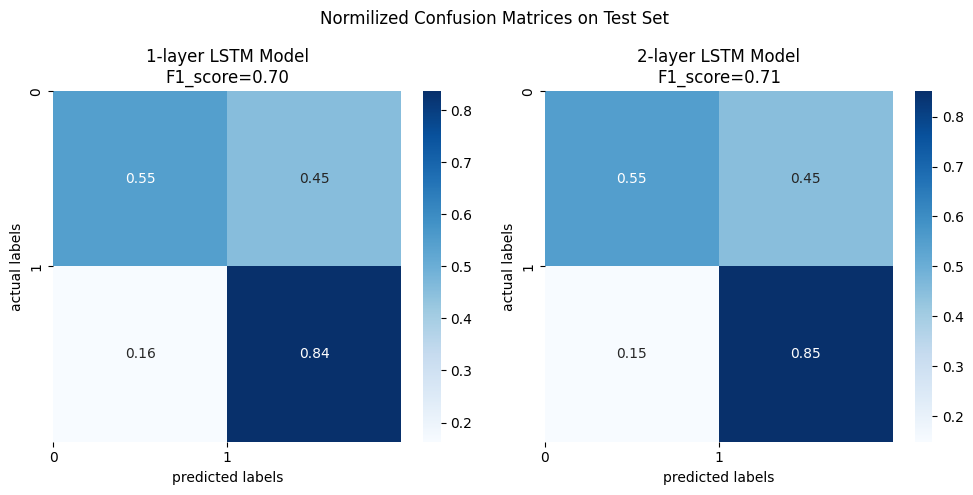

In [196]:
valid_bests = [valid_best_l1_F1s.iloc[0:1], valid_best_l2_F1s.iloc[0:1]]
test_results, confusion_matrices = test_models_with_seeds(valid_bests)
print(" ---------------------------------------------------------------------------------------------------------- ")
print(" ----------------------------------- Best Results on Test dataset ----------------------------------------- ")
print(" ---------------------------------------------------------------------------------------------------------- ")
display(test_results)
show_confusion_matrices(confusion_matrices, test_results)

## Transformers

### 📚 Libraries


In [ ]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay
from datasets import Dataset
from scipy.special import softmax
import csv
import gc
import seaborn as sns
import evaluate
from transformers import TrainingArguments, Trainer
import accelerate
from transformers import AutoTokenizer, AutoConfig
from transformers import DataCollatorWithPadding
from transformers import TFAutoModelForSequenceClassification



In [ ]:
final_predictions = {}
final_cm = {}

TRANSFORMER_BATCH_SIZE = 16
TRANSFORMER_EPOCHS = 6
TRANSFORMER_LEARNING_RATE = 5e-6

### 🪪 Dataset

In [ ]:
training_data = load_dataset("data/training.json")
print('Finished training')
validation_data = load_dataset("data/validation.json")
print('Finished validation')
test_data = load_dataset("data/test.json")
print('Finished test')

training_data = training_data[training_data['lang'] != 'es']
validation_data = validation_data[validation_data['lang'] != 'es']
test_data = test_data[test_data['lang'] != 'es']

transformer_train_data = Dataset.from_pandas(training_data)
transformer_validation_data = Dataset.from_pandas(validation_data)
transformer_test_data = Dataset.from_pandas(test_data)

pro_transformer_train_data = Dataset.from_pandas(processed_training_data)
pro_transformer_validation_data = Dataset.from_pandas(processed_validation_data)
pro_transformer_test_data = Dataset.from_pandas(processed_test_data)

        

Finished training
Finished validation
Finished test


Here we use the simple preprocessing used in the link of the task, then we remove and modify the columns to build the right dataset

source: https://huggingface.co/cardiffnlp/twitter-roberta-base-hate

In [ ]:
#standard preprocessing from cardiffnlp
def transformer_preprocess_batch(texts):
    """
    Preprocesses a batch of text by replacing user mentions and URLs with placeholders.

    This function processes a list of texts by:
    - Replacing any token starting with "@" (user mentions) with the placeholder "@user".
    - Replacing any token starting with "http" (URLs) with the placeholder "http".

    Args:
        texts (list of str): A list of text strings to preprocess.

    Returns:
        list of str: A list of preprocessed text strings.
    """
    processed_texts = []
    for text in texts:
        new_text = []
        for t in text.split(" "):
            t = '@user' if t.startswith('@') and len(t) > 1 else t
            t = 'http' if t.startswith('http') else t
            new_text.append(t)
        processed_texts.append(" ".join(new_text))
    return processed_texts

# preprocessing
transformer_train_data = transformer_train_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_validation_data = transformer_validation_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_test_data = transformer_test_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)

# generate majority vote 
def transformer_generate_labels_task1(row):
    """
    Generates a single label for a row based on the majority vote of labels in "labels_task1".

    This function assumes that `row` contains a key "labels_task1" which is a list of labels.

    Args:
        row (dict): A dictionary representing a single row of data, containing the key "labels_task1".

    Returns:
        dict: A dictionary with a single key "label", containing the majority-voted label.
    """
    return {"label": majority_vote(row["labels_task1"])}

transformer_train_data = transformer_train_data.map(transformer_generate_labels_task1)
transformer_test_data = transformer_test_data.map(transformer_generate_labels_task1)
transformer_validation_data = transformer_validation_data.map(transformer_generate_labels_task1)


# remove
transformer_train_data = transformer_train_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_validation_data = transformer_validation_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_test_data = transformer_test_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])


pro_transformer_train_data = pro_transformer_train_data.remove_columns(["id_EXIST", "lang","soft_label_task1", "original", "__index_level_0__"])
pro_transformer_train_data = pro_transformer_train_data.rename_column("hard_label_task1", "label")
pro_transformer_validation_data = pro_transformer_validation_data.remove_columns(["id_EXIST", "lang","soft_label_task1", "original", "__index_level_0__"])
pro_transformer_validation_data = pro_transformer_validation_data.rename_column("hard_label_task1", "label")
pro_transformer_test_data = pro_transformer_test_data.remove_columns(["id_EXIST", "lang","soft_label_task1", "original", "__index_level_0__"])
pro_transformer_test_data = pro_transformer_test_data.rename_column("hard_label_task1", "label")

Map: 100%|██████████| 177/177 [00:00<00:00, 5366.27 examples/s]


We can finally download the model and use the tokenizer

In [ ]:
#TODO REMOVE

In [ ]:
task='hate'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"


# download label mapping
# labels=[]
# mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
# with urllib.request.urlopen(mapping_link) as f:
#     html = f.read().decode('utf-8').split("\n")
#     csvreader = csv.reader(html, delimiter='\t')
# labels = [row[1] for row in csvreader if len(row) > 1]


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_Fast=False)

def preprocess_text(texts):
    """
    Tokenizes the text data in the 'tweet' column using the specified tokenizer.

    This function applies a Hugging Face tokenizer to preprocess and tokenize the content
    of the 'tweet' column, preparing it for model training, validation, or testing.

    Args:
        texts (dict): A dictionary containing the 'tweet' key, where the value is a list
                      of strings to be tokenized.

    Returns:
        dict: A dictionary of tokenized outputs, including input IDs, attention masks, and other
              tokenizer-specific features.
    """
    return tokenizer(texts['tweet'])

train_data = transformer_train_data.map(preprocess_text, batched=True)
val_data = transformer_validation_data.map(preprocess_text, batched=True)
test_data = transformer_test_data.map(preprocess_text, batched=True)

pro_train_data = pro_transformer_train_data.map(preprocess_text, batched=True)
pro_val_data = pro_transformer_validation_data.map(preprocess_text, batched=True)
pro_test_data = pro_transformer_test_data.map(preprocess_text, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|██████████| 312/312 [00:00<00:00, 9586.84 examples/s]


### 📏 Metrics

We encounter some problem with the "evaluate f1" from huggingface so we build this compute metrics function

source: https://huggingface.co/docs/datasets/v2.20.0/how_to_metrics

In [ ]:
def compute_metrics(prediction_label):
        """
    Computes evaluation metrics for a classification task.

    This function calculates the F1-score (macro-averaged) and accuracy
    based on the model's predictions and true labels.

    Args:
        prediction_label (tuple): A tuple containing:
            - `predictions` (array-like): Model predictions, typically as logits or probabilities.
            - `labels` (array-like): Ground truth labels.

    Returns:
        dict: A dictionary with the following keys:
            - `"f1-score"`: The macro-averaged F1-score.
            - `"Accuracy"`: The accuracy score.
    """

        predictions, labels = prediction_label
        predictions = np.array(predictions)
        labels = np.array(labels)
        predictions = np.argmax(predictions, axis=-1)

        f1 = f1_score(labels, predictions, average="macro")
        acc = accuracy_score(labels, predictions)

        return {"f1-score" : f1, "Accuracy" : acc}

### 🏋️‍♂️ Training

As previously observed the classes are not balanced, this trainer who tries to manage the problem by using the balancing weights brings better performances than the normal trainer

Initial source:
https://discuss.pytorch.org/t/cross-entropy-loss-for-imbalanced-set-binary-classification/106554

In [ ]:
# Asimple trainer but with the weight balanced

class TrainerClassWeights(Trainer):
    """
    A custom Trainer class for handling imbalanced datasets by applying class weights 
    during the loss computation.

    This class extends the Hugging Face `Trainer` class and overrides the `compute_loss` 
    method to incorporate weighted cross-entropy loss. The weights help handle 
    class imbalance effectively by penalizing the loss for underrepresented classes.

    Args:
        class_weights (torch.Tensor): A tensor of weights for each class. Typically, 
                                      higher weights are assigned to underrepresented classes.
        device (torch.device): The device on which the weights tensor should be placed 
                               (e.g., "cuda" or "cpu").
        *args: Variable length argument list for the parent `Trainer` class.
        **kwargs: Arbitrary keyword arguments for the parent `Trainer` class.
    """
    def __init__(self, class_weights, device, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.device = device

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Computes the loss during the training process, applying class weights to handle
        imbalanced datasets.

        Overrides the default `Trainer.compute_loss` method to use `CrossEntropyLoss` with 
        class weights.

        Args:
            model (torch.nn.Module): The model being trained.
            inputs (dict): A batch of input data containing:
                - `input_ids` (torch.Tensor): The tokenized input IDs.
                - `attention_mask` (torch.Tensor): Attention masks for the inputs.
                - `labels` (torch.Tensor): Ground truth labels for the inputs.
            return_outputs (bool, optional): If True, returns both the loss and model outputs.
                                            Defaults to False.
            num_items_in_batch (int, optional): Not used in this implementation, but reserved for 
                                                additional customization. Defaults to None.

        Returns:
            torch.Tensor or tuple: The computed loss, or a tuple `(loss, outputs)` if 
                                `return_outputs` is True.
        """

        if self.label_smoother is not None and "labels" in inputs:
            labels = inputs.pop("labels")
        else:
            labels = None
        outputs = model(**inputs)
        if self.args.past_index >= 0:
            self._past = outputs[self.args.past_index]

        if labels is not None:
            loss = self.label_smoother(outputs, labels)
        else:
            logits = outputs.get('logits')
            criterion = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device)) # This is the loss that permit us to threat the unbalanced class
            loss = criterion(logits, inputs['labels'])

        return (loss, outputs) if return_outputs else loss
    

In [ ]:

def sexism_roberta_cardiff(model: str, seed: int, class_weights: torch.Tensor, train_data: Dataset, val_data: Dataset, test_data: Dataset, data_collator, device: torch.device):
    
    """
    Trains and evaluates a RoBERTa model for binary classification, leveraging class weights 
    to handle imbalanced data, and saves predictions and confusion matrices for analysis.

    Args:
        model (str): The name or path of the pre-trained RoBERTa model to use (e.g., "roberta-base").
        seed (int): Random seed for reproducibility in training and data handling.
        class_weights (torch.Tensor): A tensor containing weights for each class, used to balance 
                                       the loss during training.
        train_data (Dataset): The training dataset, typically a Hugging Face `Dataset` object.
        val_data (Dataset): The validation dataset.
        test_data (Dataset): The test dataset.
        data_collator: A data collator (e.g., `DataCollatorWithPadding`) to handle batch processing.
        device (torch.device): The device on which computations will be performed (e.g., "cuda" or "cpu").

    Returns:
        None: This function modifies global variables `final_predictions` and `final_cm` 
              to store model predictions, evaluation metrics, and confusion matrices.

    """


    # We define a name that take in to account the model and the seed for the model to has metrics and plots later
    model_name = model+str(seed)
    print(type(model),type(seed),type(class_weights),type(train_data),type(val_data),type(test_data),type(data_collator),type(model_name))
    with torch.no_grad():
        torch.cuda.empty_cache()

    gc.collect()

    model = AutoModelForSequenceClassification.from_pretrained(model, num_labels=2, id2label={0: 'NEG', 1: 'POS'}, label2id={'NEG': 0, 'POS': 1})

    training_args = TrainingArguments(
        output_dir=model_name,
        learning_rate=TRANSFORMER_LEARNING_RATE,
        per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,       
        per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
        num_train_epochs=TRANSFORMER_EPOCHS,
        weight_decay=1e-5,
        eval_strategy="epoch",         
        save_strategy="epoch",                 
        save_safetensors=True,           
        load_best_model_at_end=True,
        report_to='none', # we didn't use wandb (default)
        seed=seed,
        data_seed=seed
    )

    trainer = TrainerClassWeights(
                model=model,
                args=training_args,
                train_dataset=train_data,
                eval_dataset=test_data,
                data_collator=data_collator,
                compute_metrics=compute_metrics,
                class_weights=class_weights,
                device=device,
            )
    
    

    trainer.train()

    val_prediction_label = trainer.predict(val_data)
    val_predictions, val_labels = val_prediction_label.predictions, val_prediction_label.label_ids
    val_predictions = np.argmax(val_predictions, axis=1)

    test_prediction_label = trainer.predict(test_data)
    test_predictions, test_labels = test_prediction_label.predictions, test_prediction_label.label_ids
    test_predictions = np.argmax(test_predictions, axis=1)

    final_predictions[model_name] = {'val': {}, 'test': {}}
    final_predictions[model_name]['val'] = {'predictions': val_predictions, 'labels': val_labels}
    final_predictions[model_name]['test'] = {'predictions': test_predictions, 'labels': test_labels}

    final_cm[model_name + "val"] = confusion_matrix(val_labels,val_predictions)
    final_cm[model_name + "test"] = confusion_matrix(test_labels,test_predictions)


    print(f"VAL: {val_prediction_label.metrics}")
    print(f"TEST: {test_prediction_label.metrics}")


We later implement it with different seeds for robust estimation.

Useful source: https://pytorch.org/docs/stable/notes/randomness.html

In [ ]:
sexism_roberta_cardiff(
    model = MODEL,
    seed = 42,
    class_weights = class_weight,
    train_data = train_data,
    val_data= val_data,
    test_data = test_data,
    data_collator = data_collator,
    device=device
)

<class 'str'> <class 'int'> <class 'torch.Tensor'> <class 'datasets.arrow_dataset.Dataset'> <class 'datasets.arrow_dataset.Dataset'> <class 'datasets.arrow_dataset.Dataset'> <class 'transformers.data.data_collator.DataCollatorWithPadding'> <class 'str'>


                                                  
 17%|█▋        | 204/1224 [04:42<15:17,  1.11it/s]

{'eval_loss': 0.42491599917411804, 'eval_f1-score': 0.7905283272220214, 'eval_Accuracy': 0.7916666666666666, 'eval_runtime': 4.4596, 'eval_samples_per_second': 69.961, 'eval_steps_per_second': 4.485, 'epoch': 1.0}


                                                  
 33%|███▎      | 408/1224 [09:21<15:23,  1.13s/it]

{'eval_loss': 0.42695119976997375, 'eval_f1-score': 0.803759421754328, 'eval_Accuracy': 0.8044871794871795, 'eval_runtime': 4.4541, 'eval_samples_per_second': 70.047, 'eval_steps_per_second': 4.49, 'epoch': 2.0}


...

{'eval_loss': 0.47923654317855835, 'eval_f1-score': 0.803759421754328, 'eval_Accuracy': 0.8044871794871795, 'eval_runtime': 4.3532, 'eval_samples_per_second': 71.672, 'eval_steps_per_second': 4.594, 'epoch': 6.0}


100%|██████████| 1224/1224 [28:05<00:00,  1.38s/it]


{'train_runtime': 1685.2001, 'train_samples_per_second': 11.607, 'train_steps_per_second': 0.726, 'train_loss': 0.3415389871285632, 'epoch': 6.0}


100%|██████████| 20/20 [00:04<00:00,  4.98it/s]

VAL: {'test_loss': 0.44134292006492615, 'test_f1-score': 0.8196785960761116, 'test_Accuracy': 0.8248587570621468, 'test_runtime': 2.9989, 'test_samples_per_second': 59.022, 'test_steps_per_second': 4.001}
TEST: {'test_loss': 0.42491599917411804, 'test_f1-score': 0.7905283272220214, 'test_Accuracy': 0.7916666666666666, 'test_runtime': 4.2775, 'test_samples_per_second': 72.941, 'test_steps_per_second': 4.676}


In [ ]:
sexism_roberta_cardiff(
    model = MODEL,
    seed = 42,
    class_weights = class_weight,
    train_data = pro_train_data,
    val_data= pro_val_data,
    test_data = pro_test_data,
    data_collator = data_collator,
    device=device
)

<class 'str'> <class 'int'> <class 'torch.Tensor'> <class 'datasets.arrow_dataset.Dataset'> <class 'datasets.arrow_dataset.Dataset'> <class 'datasets.arrow_dataset.Dataset'> <class 'transformers.data.data_collator.DataCollatorWithPadding'> <class 'str'>


 17%|█▋        | 204/1224 [11:21<1:05:56,  3.88s/it]

{'eval_loss': 0.44164159893989563, 'eval_f1-score': 0.794186765615337, 'eval_Accuracy': 0.7948717948717948, 'eval_runtime': 9.8586, 'eval_samples_per_second': 31.647, 'eval_steps_per_second': 2.029, 'epoch': 1.0}


 33%|███▎      | 408/1224 [4:38:27<35:41,  2.62s/it]

{'eval_loss': 0.44391539692878723, 'eval_f1-score': 0.794186765615337, 'eval_Accuracy': 0.7948717948717948, 'eval_runtime': 9.4609, 'eval_samples_per_second': 32.978, 'eval_steps_per_second': 2.114, 'epoch': 2.0}


...

{'eval_loss': 0.4634392559528351, 'eval_f1-score': 0.8103343465045593, 'eval_Accuracy': 0.8108974358974359, 'eval_runtime': 8.7273, 'eval_samples_per_second': 35.75, 'eval_steps_per_second': 2.292, 'epoch': 6.0}


100%|██████████| 1224/1224 [5:26:08<00:00, 15.99s/it]


{'train_runtime': 19568.886, 'train_samples_per_second': 1.0, 'train_steps_per_second': 0.063, 'train_loss': 0.3838779412063898, 'epoch': 6.0}


100%|██████████| 20/20 [00:08<00:00,  2.32it/s]

VAL: {'test_loss': 0.4646422863006592, 'test_f1-score': 0.8039994788952579, 'test_Accuracy': 0.807909604519774, 'test_runtime': 12.6648, 'test_samples_per_second': 13.976, 'test_steps_per_second': 0.948}
TEST: {'test_loss': 0.4399215579032898, 'test_f1-score': 0.7943309162821358, 'test_Accuracy': 0.7948717948717948, 'test_runtime': 8.7213, 'test_samples_per_second': 35.774, 'test_steps_per_second': 2.293}


### 📊 Results

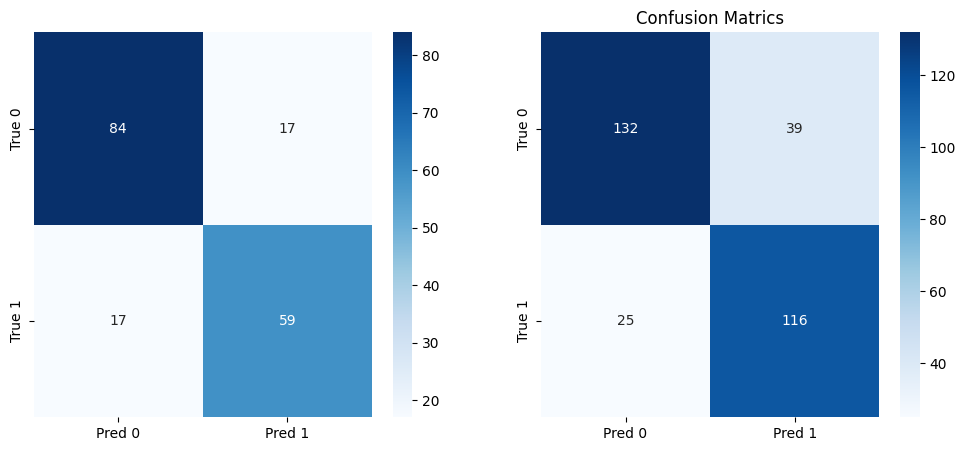

In [ ]:
plt.figure(figsize=(12,5))
for i,c in enumerate(final_cm):
    plt.subplot(1,2,i+1)
    sns.heatmap(final_cm[c], annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.suptitle('Transformer Confusion Matrics')
plt.show()

